# Task 4 — Data Transformation and Storage

**COMP5339 Data Engineering · Assignment 1 · EV Charger Data Integration & Augmentation**

---

This notebook turns the cleaned charger data from Task 2 and the augmented attributes from Task 3
into a relational database in **DuckDB with the spatial extension**. It creates the schema from a
standalone DDL script, loads every table from the upstream outputs, checks that the load is complete
and correct, runs the kinds of analytical and spatial queries the design is meant to support, and
generates the schema diagram.

| Output | Contents |
|---|---|
| `sql/schema.sql` | DDL that recreates the whole schema: 13 tables with their constraints, 2 R-tree indexes, a distance macro and 3 analysis views |
| `data/processed/ev_chargers.duckdb` | The populated database |
| `docs/schema_diagram.png` | Entity-relationship diagram, generated from the database catalog |

### How to run

Run `01_data_acquisition.ipynb`, `02_data_cleaning.ipynb` and `03_data_augmentation.ipynb` first. Section 1.2
checks for their outputs and names the notebook to run if any are missing. Then run this notebook
from top to bottom (**Kernel → Restart Kernel and Run All Cells**). A run takes about 20 seconds.
It needs no network access, except to download the DuckDB spatial extension if Tasks 1–3 have not
already installed it.

The database file is **deleted and rebuilt on every run**, so re-running is always safe and the file
on disk always matches `sql/schema.sql`.

### Contents

1. [Setup and configuration](#setup)
2. [Schema design](#design) — the decisions and the reasons for them
3. [Create the database](#create) from the DDL script
4. [Stage the upstream outputs](#stage)
5. [Load the tables](#load)
6. [Validation](#validate)
7. [Example queries](#queries)
8. [Schema diagram](#diagram)
9. [Summary and outputs](#summary)

<a id="setup"></a>
## 1. Setup and configuration

### 1.1 Dependencies

As in Tasks 1 and 2, the packages are installed from within the notebook so it runs on a fresh
machine. DuckDB must be **1.5 or newer**: the schema stores the coordinate reference system in the
geometry column type, which earlier versions do not support.

In [1]:
%pip install -q "duckdb>=1.5" "pandas>=2.2" "numpy>=1.26" "matplotlib>=3.8"

Note: you may need to restart the kernel to use updated packages.


In [2]:
import json
import re
import sys
from pathlib import Path

import duckdb
import numpy as np
import pandas as pd
from IPython.display import Image, display

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 60)

print(f"duckdb {duckdb.__version__} | pandas {pd.__version__}")

duckdb 1.5.5 | pandas 2.3.3


### 1.2 Configuration and inputs

Task 4 depends on the *outputs* of Tasks 1–3, never on their in-memory variables. Every input is
listed here together with the notebook that produces it. If any is missing, the cell stops with a
message saying which notebook to run, instead of failing later halfway through a load.

In [3]:
# --- Paths -------------------------------------------------------------------
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
INTERIM_DIR = DATA_DIR / "interim"
PROCESSED_DIR = DATA_DIR / "processed"

DDL_PATH = PROJECT_ROOT / "sql" / "schema.sql"
DB_PATH = PROCESSED_DIR / "ev_chargers.duckdb"
DIAGRAM_PATH = PROJECT_ROOT / "docs" / "schema_diagram.png"

# --- Upstream outputs: (path, the notebook or script that produces it) --------
INPUTS = {
    "chargers_full":    (INTERIM_DIR / "ev_chargers_augmented_full.csv", "03_data_augmentation.ipynb"),
    "chargers_final":   (PROCESSED_DIR / "ev_chargers_augmented.csv", "03_data_augmentation.ipynb"),
    "ocm_review":       (INTERIM_DIR / "ocm_matching_review.csv", "03_data_augmentation.ipynb"),
    "plugshare_review": (INTERIM_DIR / "plugshare_matching_review.csv", "03_data_augmentation.ipynb"),
    "chargers_clean":   (INTERIM_DIR / "ev_chargers_clean.csv", "02_data_cleaning.ipynb"),
    "power_ratings":    (INTERIM_DIR / "charger_power_ratings.csv", "02_data_cleaning.ipynb"),
    "duplicates":       (INTERIM_DIR / "probable_duplicates.csv", "02_data_cleaning.ipynb"),
    "sa4_nsw":          (INTERIM_DIR / "sa4_regions_nsw.csv", "02_data_cleaning.ipynb"),
    "manifest":         (RAW_DIR / "manifest.json", "01_data_acquisition.ipynb"),
    "ocm_metadata":     (RAW_DIR / "openchargemap" / "locations.metadata.json", "03_data_augmentation.ipynb"),
    "plugshare_cache":  (RAW_DIR / "plugshare" / "coordinate_searches.json", "tools/Plug_share.py"),
    "ddl":              (DDL_PATH, "sql/schema.sql (part of this project)"),
}
missing = [
    f"  {path.relative_to(PROJECT_ROOT)}  <- produced by {producer}"
    for path, producer in INPUTS.values()
    if not path.exists()
]
if missing:
    raise FileNotFoundError("Missing upstream outputs; run these first:\n" + "\n".join(missing))
PATHS = {name: path for name, (path, _) in INPUTS.items()}

MANIFEST = json.loads(PATHS["manifest"].read_text(encoding="utf-8"))["artefacts"]
SA4_SHAPEFILE_PATH = PROJECT_ROOT / MANIFEST["abs_asgs_sa4_boundaries"]["shapefile"]
if not SA4_SHAPEFILE_PATH.exists():
    raise FileNotFoundError(f"{SA4_SHAPEFILE_PATH.relative_to(PROJECT_ROOT)} is missing - run Task 1")

# --- Constants shared with Tasks 2 and 3 -----------------------------------------
SOURCE_CRS = "EPSG:7844"       # GDA2020, the datum of the ABS boundaries
TARGET_CRS = "EPSG:4326"       # WGS84, the datum of the TfNSW coordinates
NSW_STATE_NAME = "New South Wales"
NEAREST_TOLERANCE_M = 2_000    # Task 2 assigned off-coast points to an SA4 within ~2 km

# Storage format v1.5.0 is the oldest that keeps the CRS of a GEOMETRY('EPSG:4326')
# column on disk (section 3). It is pinned rather than set to 'latest', so the file
# stays readable by any DuckDB 1.5.x and not only by the version that wrote it.
DB_STORAGE_VERSION = "v1.5.0"

print("All inputs present:")
for name, path in PATHS.items():
    print(f"  {name:<17} {path.relative_to(PROJECT_ROOT)}")

All inputs present:
  chargers_full     data/interim/ev_chargers_augmented_full.csv
  chargers_final    data/processed/ev_chargers_augmented.csv
  ocm_review        data/interim/ocm_matching_review.csv
  plugshare_review  data/interim/plugshare_matching_review.csv
  chargers_clean    data/interim/ev_chargers_clean.csv
  power_ratings     data/interim/charger_power_ratings.csv
  duplicates        data/interim/probable_duplicates.csv
  sa4_nsw           data/interim/sa4_regions_nsw.csv
  manifest          data/raw/manifest.json
  ocm_metadata      data/raw/openchargemap/locations.metadata.json
  plugshare_cache   data/raw/plugshare/coordinate_searches.json
  ddl               sql/schema.sql


<a id="design"></a>
## 2. Schema design

The brief asks for a schema that supports "efficient storage and querying of charger locations,
operators, charger characteristics, and geographic regions". Task 3 hands over one flat file with
one row per charger: 22 columns in the processed version, 66 in the audit version. A flat file is
easy to produce, but it repeats many facts on every row. Worse, several facts in this data cannot
be held in one row per charger without discarding information or encoding it as text.

### 2.1 From one flat file to entities

Each table exists because a group of columns depends on a key other than `charger_id`. Section 5
checks each such dependency against the data before loading.

| Table | Key | Why it is a separate table |
|---|---|---|
| `location` | coordinates (Task 2's `site_id`) | SA4 region, postcode and address describe *where* a charger is, not *which* charger it is. Ten sites hold more than one charger, for example a Tesla DC unit and a non-networked AC unit at 19 Princes Hwy, Figtree. Section 5.4 confirms that coordinates, postcode and SA4 never vary within a site. |
| `operator` | operator name | The website and the truncation flag describe the company. On the flat file, Tesla's website would be repeated on 285 rows, free to drift between them. |
| `state` ← `gccsa` ← `sa4_region` | ABS codes | The ASGS hierarchy. `gcc_name` depends on `gcc_code`, not on `sa4_code`, so storing it with every SA4 (as the flat file does with every charger) is a transitive dependency. |
| `charger_duplicate` | charger | Task 2 flags 23 records as the same charger listed in a second TfNSW feed. The rule that linked each pair, and the distance between the two points, describe the *pair*, not either charger. So they live in a link table with two foreign keys to `charger`, instead of as three mostly-empty columns on it. |
| `charger_power_rating` | (charger, component) | `2x350kW & 2x175kW` is a *repeating group*: two groups of connectors at different powers. No single `power_kw` value can hold it. |
| `charger_connector` + `connector_type` | (charger, connector) | Task 3 stores plug types as a text list, `CCS2; CHAdeMO`, which breaks first normal form: "which chargers offer CHAdeMO?" becomes a substring search. A bridge table turns it into a join, and the lookup table fixes the vocabulary. |
| `charger_match` | (charger, source) | Every match Task 3 attempted, whatever the outcome, with its distance and reason. Augmentation coverage and provenance become queryable. |
| `tariff_observation` | observation | Prices change. Stored as time-stamped observations rather than as a column on `charger`, the repeated price retrievals of Assignment 2 append history instead of overwriting it. |
| `data_source` | source | Provenance: where each dataset came from, how it was accessed, under what licence and when. Every augmented value points to one. |

### 2.2 Normalised tables, denormalised views

The base tables are in **third normal form**. The obvious alternative, a star schema around one
wide fact table, is the usual analytical design, and DuckDB handles wide tables well. It was not
used for the base tables because the problems in *this* data are problems of consistency: one site
reported twice with differently formatted addresses, and 50 operator spellings for about 35
companies. In a normalised schema each fact is stored once, so it cannot contradict itself. At about
2,000 chargers, the joins this costs are negligible.

Analysts still get the flat shape, through three views:

* `v_charger_detail`: one row per charger, with everything joined back in. Section 6.3 shows that
  it reproduces Task 3's output file.
* `v_sa4_coverage`: chargers, DC chargers, plugs and DC density per SA4 region, including any
  region with none.
* `v_operator_summary`: the size and geographic spread of each operator.

**Derived values exist only in views:** minimum and maximum power, the rating format, plug-type
lists and all counts. A stored copy of a derived value can fall out of step with the data it came
from; a view cannot.

### 2.3 Spatial design

* **The CRS is part of the column type.** Both geometry columns are `GEOMETRY('EPSG:4326')`, and
  DuckDB checks the CRS on insert. An SA4 polygon still in GDA2020 (EPSG:7844) is *rejected* rather
  than stored next to WGS84 points (section 6.2). The reprojection Task 2 performed becomes a rule
  the schema enforces, not one every loader must remember.
* **Points and full-resolution polygons are both stored**, so Assignment 2 can run point-in-polygon,
  distance and buffer queries without re-reading the shapefile.
* **R-tree indexes on both geometry columns.** DuckDB's zone maps serve ordinary filters; spatial
  predicates cannot use them.
* **Latitude and longitude are also kept as plain numbers**, for export to non-spatial tools. A
  CHECK constraint ties them to the point geometry, which also makes a longitude/latitude swap
  impossible to store.
* **`distance_m(a, b)`** is a stored SQL macro that returns metres on the WGS84 ellipsoid.
  `ST_Distance` on longitude/latitude returns *degrees*, and `ST_Distance_Spheroid` expects
  *latitude-first* input; the macro hides both pitfalls.
* **Two ABS codes are left out.** `197 Migratory - Offshore - Shipping (NSW)` and
  `199 No usual address (NSW)` are ABS non-spatial codes with no boundary, so no charger can lie in
  them. Task 2 keeps them in its region table marked `has_boundary = False`, and every NSW SA4
  region that does have a boundary has chargers.

### 2.4 Keys and integrity

* `charger_id` and `location_id` are Task 2's `charger_id` and `site_id`, unchanged, so any
  database row traces straight back to the interim CSVs and to Task 3's matching reviews. The lookup
  keys `operator_id` and `connector_type_id` are numbered alphabetically, so a rebuild reproduces the
  same IDs. `tariff_observation` takes its key from a sequence, because Assignment 2 will append to it.
* **Constraints turn the cleaning rules into a contract.** `charger_type` is AC or DC and may be
  NULL only for an Upcoming site. Postcodes have four digits. An external ID exists if and only if a
  match was accepted, and no accepted match is more than 250 m away. A price range has min ≤ max. A
  future TfNSW release that breaks one of these rules is refused at load time, instead of producing a
  wrong number later.
* DuckDB foreign keys do not support `ON DELETE CASCADE`, and a referenced key cannot be updated.
  This database is a derived artefact that this notebook rebuilds from scratch, so neither
  limitation matters here.

### 2.5 Decisions at a glance

| Decision | Chosen | Rejected alternative, and why |
|---|---|---|
| Base schema | 3NF tables + views | One wide table or star schema: repeats operator and region facts on every charger row |
| Site vs charger | separate `location` table | Address and SA4 on `charger`: co-located chargers could disagree about where they are |
| Plug types | bridge table + lookup | `'CCS2; CHAdeMO'` text: needs string matching, no controlled vocabulary |
| Power rating | one row per connector group | `power_kw_max` only: discards the second group of every compound rating |
| Prices | time-stamped observations, raw text + parsed numbers | Column on `charger`: overwritten on refresh. Numbers only: loses conditions such as member discounts |
| Geometry | `GEOMETRY('EPSG:4326')` + R-tree | WKT text or lat/lon only: no spatial predicates, no index, no CRS check |
| LGA | attribute of `location` | Own table: the source gives only a name, with no code or boundary, so a table would add a join and no information |
| Non-spatial SA4 codes | excluded | Included with NULL geometry: `geom` would lose its NOT NULL guarantee, and the coverage view would list two "empty regions" that are not places |
| Probable duplicates | link table `charger_duplicate`; flagged, not merged | Merging: the evidence is strong but not conclusive (Task 2, section 9.1). Columns on `charger`: the rule and distance belong to the pair |
| Derived values | computed in views | Stored columns: can go stale |

<a id="create"></a>
## 3. Create the database

The database is a derived artefact, so it is rebuilt from nothing on every run. That has a useful
side effect: `sql/schema.sql` is *exercised* on every run, not merely claimed to recreate the
schema. If the DDL and the loading code ever disagree, this notebook fails.

The file is created in storage format v1.5.0, and that setting is not cosmetic. DuckDB's default
on-disk format, which stays readable by v0.10, **silently drops the CRS from
`GEOMETRY('EPSG:4326')` columns when the file is saved**. After reopening, the columns report plain
`GEOMETRY`, and the CRS check of section 2.3 is gone. The DDL script therefore begins with a guard
that refuses to run against an older-format file. The cost is that opening the database file
requires DuckDB 1.5 or later.

In [4]:
# Remove the previous build, including a write-ahead log left by an interrupted run.
for stale in (DB_PATH, DB_PATH.with_name(DB_PATH.name + ".wal")):
    stale.unlink(missing_ok=True)
DB_PATH.parent.mkdir(parents=True, exist_ok=True)

con = duckdb.connect(str(DB_PATH), config={"storage_compatibility_version": DB_STORAGE_VERSION})
con.execute(DDL_PATH.read_text(encoding="utf-8"))

storage_version = con.execute("""
    SELECT tags['storage_version'] FROM duckdb_databases()
    WHERE database_name = current_database()
""").fetchone()[0]
print(f"Created {DB_PATH.relative_to(PROJECT_ROOT)} (storage format {storage_version}) "
      f"from {DDL_PATH.relative_to(PROJECT_ROOT)}")

display(con.sql("""
    SELECT table_name, column_count, comment
    FROM duckdb_tables()
    WHERE database_name = current_database()
    ORDER BY table_name
""").df())
display(con.sql("""
    SELECT 'view' AS kind, view_name AS name FROM duckdb_views()
    WHERE schema_name = 'main' AND NOT internal
    UNION ALL
    SELECT 'index', index_name || ' on ' || table_name FROM duckdb_indexes()
    UNION ALL
    SELECT DISTINCT 'macro', function_name FROM duckdb_functions() WHERE function_name = 'distance_m'
    ORDER BY kind, name
""").df())

Created data/processed/ev_chargers.duckdb (storage format v1.5.0+) from sql/schema.sql


,table_name,column_count,comment
0,charger,16,"EV chargers from the TfNSW December 2025 release, cleane..."
1,charger_connector,3,"Plug standards available at each charger (augmented, Tas..."
2,charger_duplicate,4,Probable duplicates: a record that is the same charger a...
3,charger_match,9,Outcome of every attempted match of a DC charger against...
4,charger_power_rating,4,Connector groups parsed from the TfNSW power rating; one...
5,connector_type,2,Controlled vocabulary of plug standards.
6,data_source,7,Provenance of every dataset loaded or used for augmentat...
7,gccsa,3,ABS Greater Capital City Statistical Areas; each belongs...
8,location,12,"Physical charger sites: one row per distinct coordinate,..."
9,operator,6,"Charging network operators, canonicalised in Task 2 and ..."


,kind,name
0,index,idx_location_geom on location
1,index,idx_sa4_region_geom on sa4_region
2,macro,distance_m
3,view,v_charger_detail
4,view,v_operator_summary
5,view,v_sa4_coverage


<a id="stage"></a>
## 4. Stage the upstream outputs

The CSVs are read with explicit types, following Task 2's rule that type inference is where data is
first changed without anyone deciding it should be. Postcodes and ABS codes are read as text; IDs as
pandas' nullable `Int64`, so a missing `ocm_id` does not turn the whole column into floats. Each
frame is registered with DuckDB as a view (`stg_*`), without copying it. The `INSERT … SELECT`
statements in section 5 therefore do the transformation in SQL, inside the engine that stores the
result.

One count changes between tasks. Task 2 produced 1,946 chargers, and Task 3 removed 6 of them as
duplicates: pairs of source rows that had matched the same Open Charge Map site (Task 3, section
2.1). The database follows Task 3's final record set.

In [5]:
TEXT_CODES = {"postcode": "string", "postcode_reported": "string",
              "sa4_code": "string", "gcc_code": "string"}

chargers_full = pd.read_csv(
    PATHS["chargers_full"],
    dtype={**TEXT_CODES, "source_object_id": "Int64", "ocm_id": "Int64", "plugshare_id": "string"},
)
ocm_review = pd.read_csv(PATHS["ocm_review"],
                         dtype={"postcode": "string", "candidate_ocm_id": "Int64"})
plugshare_review = pd.read_csv(PATHS["plugshare_review"],
                               dtype={"postcode": "string", "plugshare_id": "string"})
power_ratings = pd.read_csv(PATHS["power_ratings"])
duplicates = pd.read_csv(PATHS["duplicates"])
task2_charger_ids = pd.read_csv(PATHS["chargers_clean"], usecols=["charger_id"])["charger_id"]

# Structural assumptions the loaders rely on, checked before anything is written.
assert chargers_full["charger_id"].is_unique
assert chargers_full[["latitude", "longitude"]].notna().all().all()
flag_columns = [c for c in chargers_full.columns if c.endswith("_flag")] + ["augmented"]
assert all(chargers_full[c].dtype == bool for c in flag_columns), "flags must parse as booleans"

staged = {
    "stg_charger": (chargers_full, "chargers_full"),
    "stg_ocm_review": (ocm_review, "ocm_review"),
    "stg_plugshare_review": (plugshare_review, "plugshare_review"),
    "stg_power_rating": (power_ratings, "power_ratings"),
    "stg_charger_duplicate": (duplicates, "duplicates"),
}
for view_name, (frame, _) in staged.items():
    con.register(view_name, frame)

display(pd.DataFrame(
    [(view_name, str(PATHS[key].relative_to(PROJECT_ROOT)), len(frame), frame.shape[1])
     for view_name, (frame, key) in staged.items()],
    columns=["staged view", "source file", "rows", "columns"],
))
removed_by_task3 = len(task2_charger_ids) - len(chargers_full)
print(f"Chargers: {len(task2_charger_ids):,} after Task 2 -> {len(chargers_full):,} after Task 3 "
      f"({removed_by_task3} duplicates removed by Task 3)")

,staged view,source file,rows,columns
0,stg_charger,data/interim/ev_chargers_augmented_full.csv,1940,67
1,stg_ocm_review,data/interim/ocm_matching_review.csv,431,40
2,stg_plugshare_review,data/interim/plugshare_matching_review.csv,311,29
3,stg_power_rating,data/interim/charger_power_ratings.csv,1527,4
4,stg_charger_duplicate,data/interim/probable_duplicates.csv,23,4


Chargers: 1,946 after Task 2 -> 1,940 after Task 3 (6 duplicates removed by Task 3)


<a id="load"></a>
## 5. Load the tables

Tables are loaded parents first, in foreign-key order. DuckDB checks every foreign key as rows
arrive, so a child row can never reference a missing parent. Section 6.1 reconciles every table's
row count against the inputs.

### 5.1 Geographic regions

The boundaries are read straight from the ABS shapefile with `ST_Read`, because Task 2's
`sa4_regions_nsw.csv` has no geometry. They are reprojected with the same
`ST_Transform(…, always_xy := true)` call Task 2 used for its spatial join, so the stored polygons
are exactly the ones the chargers were assigned against. The CSV then serves as a cross-check: the
two sources must agree on every code, name and area.

In [6]:
con.execute(f"""
    CREATE OR REPLACE TEMP TABLE stg_sa4 AS
    SELECT SA4_CODE26 AS sa4_code, SA4_NAME26 AS sa4_name,
           GCC_CODE26 AS gcc_code, GCC_NAME26 AS gcc_name,
           STE_CODE26 AS state_code, STE_NAME26 AS state_name,
           AREASQKM26 AS area_sqkm, geom
    FROM ST_Read('{SA4_SHAPEFILE_PATH.as_posix()}')
    WHERE STE_NAME26 = '{NSW_STATE_NAME}'
""")

print("ABS non-spatial codes, excluded from sa4_region (no boundary, no area):")
display(con.sql("""
    SELECT sa4_code, sa4_name, area_sqkm FROM stg_sa4 WHERE geom IS NULL ORDER BY sa4_code
""").df())

con.execute(f"""
    INSERT INTO state
    SELECT DISTINCT state_code, state_name FROM stg_sa4 WHERE geom IS NOT NULL;

    INSERT INTO gccsa
    SELECT DISTINCT gcc_code, gcc_name, state_code
    FROM stg_sa4 WHERE geom IS NOT NULL ORDER BY gcc_code;

    INSERT INTO sa4_region
    SELECT sa4_code, sa4_name, gcc_code, area_sqkm,
           ST_Transform(geom, '{SOURCE_CRS}', '{TARGET_CRS}', always_xy := true)
    FROM stg_sa4
    WHERE geom IS NOT NULL
    ORDER BY sa4_code;
""")

# Cross-check against Task 2's region table: identical apart from the two non-spatial codes.
task2_sa4 = pd.read_csv(PATHS["sa4_nsw"], dtype={"sa4_code": "string", "gcc_code": "string"})
db_sa4 = con.sql("""
    SELECT s.sa4_code, s.sa4_name, s.gcc_code, g.gcc_name, ROUND(s.area_sqkm, 1) AS area_sqkm
    FROM sa4_region AS s JOIN gccsa AS g USING (gcc_code)
""").df()
region_check = task2_sa4.merge(db_sa4, on="sa4_code", how="left", suffixes=("_task2", "_db"))
non_spatial_codes = set(con.sql("SELECT sa4_code FROM stg_sa4 WHERE geom IS NULL").df()["sa4_code"])
kept = region_check.dropna(subset=["sa4_name_db"])

assert set(region_check.loc[region_check["sa4_name_db"].isna(), "sa4_code"]) == non_spatial_codes
assert (kept["sa4_name_task2"] == kept["sa4_name_db"]).all()
assert (kept["gcc_code_task2"] == kept["gcc_code_db"]).all()
assert np.allclose(kept["area_sqkm_task2"], kept["area_sqkm_db"])
print(f"Cross-check with {PATHS['sa4_nsw'].name}: all {len(kept)} regions agree on "
      "code, name, GCCSA and area.")

display(con.sql("""
    SELECT (SELECT COUNT(*) FROM state)                     AS states,
           (SELECT COUNT(*) FROM gccsa)                     AS gccsas,
           COUNT(*)                                         AS sa4_regions,
           CAST(SUM(ST_NPoints(geom)) AS BIGINT)            AS boundary_vertices,
           COUNT(*) FILTER (WHERE NOT ST_IsValid(geom))     AS invalid_polygons
    FROM sa4_region
""").df())

ABS non-spatial codes, excluded from sa4_region (no boundary, no area):


,sa4_code,sa4_name,area_sqkm
0,197,Migratory - Offshore - Shipping (NSW),NaN
1,199,No usual address (NSW),NaN


Cross-check with sa4_regions_nsw.csv: all 28 regions agree on code, name, GCCSA and area.


,states,gccsas,sa4_regions,boundary_vertices,invalid_polygons
0,1,2,28,755051,0


### 5.2 Data sources

There are four sources. Their provenance comes from the files that recorded it at retrieval time:
`manifest.json` (Task 1), the OCM snapshot metadata and the PlugShare cache (Task 3). The only
values stated here by hand are the two licences that no file records, copied as published:
data.gov.au lists the TfNSW dataset under CC BY 3.0 Australia, and the ABS publishes its boundaries
under CC BY 4.0. The OCM licence is the one OCM returns with each location.

The `source_name` values for OCM and PlugShare match the `plug_type_source` labels Task 3 wrote, so
plug types join to their source without a mapping table.

In [7]:
ocm_metadata = json.loads(PATHS["ocm_metadata"].read_text(encoding="utf-8"))
plugshare_cache = json.loads(PATHS["plugshare_cache"].read_text(encoding="utf-8"))
# PlugShare was queried once per charger; the source row records when retrieval
# began, and each charger_match row keeps its own search's timestamp.
plugshare_started = min(entry["downloaded_at"] for entry in plugshare_cache["searches"].values()
                        if entry.get("downloaded_at"))
tfnsw, abs_sa4 = MANIFEST["tfnsw_ev_charging_locations"], MANIFEST["abs_asgs_sa4_boundaries"]

data_sources = pd.DataFrame([
    {"source_id": 1, "source_code": "tfnsw",
     "source_name": "Transport for NSW EV Charging Locations",
     "access_method": f"CSV download; URL discovered via {tfnsw['discovery_method']}",
     "url": tfnsw["url"], "licence": "Creative Commons Attribution 3.0 Australia",
     "retrieved_at": tfnsw["retrieved_at"]},
    {"source_id": 2, "source_code": "abs",
     "source_name": "ABS ASGS Edition 4 SA4 boundaries",
     "access_method": f"Shapefile ZIP download; URL discovered via {abs_sa4['discovery_method']}",
     "url": abs_sa4["url"], "licence": "Creative Commons Attribution 4.0 International",
     "retrieved_at": abs_sa4["retrieved_at"]},
    {"source_id": 3, "source_code": "ocm", "source_name": "Open Charge Map",
     "access_method": "REST API v3 /poi: one bounding-box query with an API key",
     "url": ocm_metadata["endpoint"],
     "licence": chargers_full["ocm_license"].dropna().mode().iat[0],
     "retrieved_at": ocm_metadata["retrieved_at"]},
    {"source_id": 4, "source_code": "plugshare", "source_name": "PlugShare",
     "access_method": "Apify actor getascraper/plugshare-scraper: 1 km search around each charger",
     "url": "https://www.plugshare.com", "licence": "Proprietary (PlugShare terms of use)",
     "retrieved_at": plugshare_started},
])
con.register("stg_data_source", data_sources)
con.execute("""
    INSERT INTO data_source
    SELECT source_id, source_code, source_name, access_method, url, licence,
           CAST(retrieved_at AS TIMESTAMPTZ)
    FROM stg_data_source
    ORDER BY source_id
""")
SOURCE_ID = dict(con.execute("SELECT source_code, source_id FROM data_source").fetchall())
display(con.sql("SELECT source_id, source_code, source_name, licence, retrieved_at FROM data_source").df())

,source_id,source_code,source_name,licence,retrieved_at
0,1,tfnsw,Transport for NSW EV Charging Locations,Creative Commons Attribution 3.0 Australia,2026-09-22 18:13:37+10:00
1,2,abs,ABS ASGS Edition 4 SA4 boundaries,Creative Commons Attribution 4.0 International,2026-09-22 18:13:37+10:00
2,3,ocm,Open Charge Map,Licensed under Creative Commons Attribution 4.0 Internat...,2026-09-21 03:53:21.915829+10:00
3,4,plugshare,PlugShare,Proprietary (PlugShare terms of use),2026-09-21 08:35:24.481186+10:00


### 5.3 Operators

One row per canonical operator name from Task 2. Two attributes need a rule.

* **`website_url`** comes from Open Charge Map's operator record, but only from accepted matches in
  which OCM names the *same* operator. Task 3's rules can also accept a candidate when the operator
  is unknown on one side, for example a `Non-networked` charger within 50 m of an OCM site with a
  similar address, and that candidate's website would belong to a different company. None of the
  accepted matches in this snapshot is of that kind (the output below counts them). The filter
  exists so that a future OCM refresh cannot attach one company's website to another. Where one
  operator has several URLs (OCM lists Tesla under two programmes), the most frequent is kept, with
  ties broken alphabetically.
* **`name_truncated`** is Task 2's `operator_truncated_flag`. The flag depends only on the operator
  name, so it moves from the charger to the operator, where it belongs.

In [8]:
con.execute(f"""
    INSERT INTO operator
    WITH names AS (
        SELECT operator AS operator_name,
               bool_or(operator_truncated_flag) AS name_truncated
        FROM stg_charger
        GROUP BY operator
    ), website_votes AS (
        -- Only accepted matches where OCM names the same company count as evidence.
        SELECT operator AS operator_name, ocm_operator_website AS website_url, COUNT(*) AS votes
        FROM stg_charger
        WHERE match_status = 'accepted'
          AND ocm_operator = operator
          AND ocm_operator_website IS NOT NULL
        GROUP BY operator, ocm_operator_website
    ), websites AS (
        SELECT operator_name, website_url
        FROM website_votes
        QUALIFY ROW_NUMBER() OVER (PARTITION BY operator_name
                                   ORDER BY votes DESC, website_url) = 1
    )
    SELECT ROW_NUMBER() OVER (ORDER BY lower(n.operator_name), n.operator_name) AS operator_id,
           n.operator_name,
           n.operator_name <> 'Non-networked'                   AS is_networked,
           n.name_truncated,
           w.website_url,
           CASE WHEN w.website_url IS NOT NULL THEN {SOURCE_ID['ocm']} END AS website_source_id
    FROM names AS n
    LEFT JOIN websites AS w USING (operator_name)
    ORDER BY operator_id
""")

print(con.sql("""
    SELECT COUNT(*) AS operators, COUNT(website_url) AS with_website,
           COUNT(*) FILTER (WHERE name_truncated) AS name_truncated,
           COUNT(*) FILTER (WHERE NOT is_networked) AS not_networked
    FROM operator
""").df().to_string(index=False))
print(con.sql("""
    SELECT COUNT(*) FILTER (WHERE ocm_operator = operator)                AS same_operator,
           COUNT(*) FILTER (WHERE ocm_operator IS DISTINCT FROM operator) AS other_or_unknown
    FROM stg_charger WHERE match_status = 'accepted'
""").df().to_string(index=False), "  <- accepted OCM matches used / not used as website evidence\n")

display(con.sql("""
    SELECT s.operator AS operator_name, s.ocm_operator_website AS candidate_url,
           COUNT(*) AS matches, any_value(o.website_url = s.ocm_operator_website) AS kept
    FROM stg_charger AS s
    JOIN operator AS o ON o.operator_name = s.operator
    WHERE s.match_status = 'accepted' AND s.ocm_operator = s.operator
      AND s.ocm_operator_website IS NOT NULL
    GROUP BY s.operator, s.ocm_operator_website
    ORDER BY operator_name, matches DESC
""").df())

 operators  with_website  name_truncated  not_networked
        42             8               3              1


 same_operator  other_or_unknown
           114                 0   <- accepted OCM matches used / not used as website evidence



,operator_name,candidate_url,matches,kept
0,Ampol,https://ampcharge.ampol.com.au/,3,True
1,BP Australia,https://www.bp.com/en_au/australia/home/products-service...,9,True
2,Chargefox,https://chargefox.com,15,True
3,Everty,https://everty.com.au/,1,True
4,Evie Networks,http://goevie.com.au/,30,True
5,JOLT,https://joltcharge.com,5,True
6,NRMA,https://www.mynrma.com.au/cars-and-driving/electric-vehi...,24,True
7,Tesla,https://www.tesla.com/en_AU/support/non-tesla-supercharging,14,True
8,Tesla,http://www.teslamotors.com,13,False


### 5.4 Locations

Before a column moves from `charger` to `location`, the data must support the move: the column must
not vary between chargers at the same site. The check below counts, for each candidate column, the
multi-charger sites at which its value varies. A missing value counts as a value here, so "missing
at one charger, present at another" shows up as variation.

In [9]:
multi_charger_sites = chargers_full[chargers_full.duplicated("site_id", keep=False)]
LOCATION_DEFINING = ["latitude", "longitude", "postcode", "sa4_code", "sa4_match_method"]
ADDRESS_DERIVED = ["station_address", "lga_name", "postcode_valid_flag",
                   "postcode_conflict_flag", "locality_placeholder_flag"]

variation = pd.DataFrame({
    "sites where it varies": {
        column: int((multi_charger_sites.groupby("site_id")[column].nunique(dropna=False) > 1).sum())
        for column in LOCATION_DEFINING + ADDRESS_DERIVED
    }
}).rename_axis("column")
print(f"{multi_charger_sites['site_id'].nunique()} sites hold more than one charger "
      f"({len(multi_charger_sites)} chargers)")
display(variation.T)

# The dependency site -> coordinates, postcode, SA4 must hold exactly.
assert (variation.loc[LOCATION_DEFINING, "sites where it varies"] == 0).all()

10 sites hold more than one charger (21 chargers)


column,latitude,longitude,postcode,sa4_code,sa4_match_method,station_address,lga_name,postcode_valid_flag,postcode_conflict_flag,locality_placeholder_flag
sites where it varies,0,0,0,0,0,10,4,0,0,2


The five location-defining columns never vary within a site, so the dependency
`site → coordinates, postcode, SA4` holds and those columns move to `location`.

The address varies at every shared site, the LGA at four, and the locality-placeholder flag, which
is computed from the address text, at two. Mostly the differences are formatting
(`19 Princes Hwy, Figtree NSW 2525` against `…, Australia`) or a value missing from one record. One
site even gives two street numbers, 50 and 52 Pembroke St, Ashfield, for a single coordinate. These
columns need a rule, and it is the one Task 2 used to reconcile conflicting duplicates: keep the
most complete value. A site takes its address, and the flags derived from that address, from
the charger with the longest address; it takes its LGA from the first charger in the same order that
has one. The alternative spellings are not lost: each charger keeps its original text in
`charger.station_address_raw`.

One LGA disagreement is genuine rather than missing data. At 260 Victoria Ave, Chatswood, one record
says North Sydney Council and the other Willoughby City Council. The rule keeps Willoughby, from the
record with the fuller address, and Willoughby is the correct council for that address.

In [10]:
con.execute("""
    INSERT INTO location
    WITH ranked AS (
        SELECT *,
               ROW_NUMBER() OVER (PARTITION BY site_id
                                  ORDER BY length(station_address) DESC, charger_id) AS rank_in_site
        FROM stg_charger
    ), site_lga AS (
        SELECT site_id,
               first(lga_name ORDER BY length(station_address) DESC, charger_id)
                   FILTER (WHERE lga_name IS NOT NULL) AS lga_name
        FROM stg_charger
        GROUP BY site_id
    )
    SELECT r.site_id, r.latitude, r.longitude, ST_Point(r.longitude, r.latitude),
           r.station_address, r.postcode, l.lga_name, r.sa4_code, r.sa4_match_method,
           r.postcode_valid_flag, r.postcode_conflict_flag, r.locality_placeholder_flag
    FROM ranked AS r
    JOIN site_lga AS l USING (site_id)
    WHERE r.rank_in_site = 1
    ORDER BY r.site_id
""")
print(f"{con.sql('SELECT COUNT(*) FROM location').fetchone()[0]:,} locations loaded\n")

print("How the shared sites were consolidated:")
display(con.sql("""
    SELECT s.site_id, s.charger_id, s.operator,
           s.station_address                   AS charger_address,
           l.station_address = s.station_address AS address_kept,
           s.lga_name                          AS charger_lga,
           l.lga_name                          AS location_lga
    FROM stg_charger AS s
    JOIN location AS l ON l.location_id = s.site_id
    WHERE s.site_id IN (SELECT site_id FROM stg_charger GROUP BY site_id HAVING COUNT(*) > 1)
    ORDER BY s.site_id, s.charger_id
""").df())

1,929 locations loaded

How the shared sites were consolidated:


,site_id,charger_id,operator,charger_address,address_kept,charger_lga,location_lga
0,246,246,Non-networked,"19 Princes Hwy, Figtree NSW 2525",False,Wollongong City Council,Wollongong City Council
1,246,247,Tesla,"19 Princes Hwy, Figtree NSW 2525, Australia",True,Wollongong City Council,Wollongong City Council
2,479,480,Chargefox,"345 Victoria Ave, Sydney, 2067",False,Willoughby City Council,Willoughby City Council
3,479,481,Engie,"345 Victoria Ave, Chatswood NSW 2067",True,Willoughby City Council,Willoughby City Council
4,483,485,Engie,"3-5 Underwood Rd, Homebush NSW 2140",False,Strathfield Municipal Council,Strathfield Municipal Council
5,483,486,Tesla,3-5 Underwood Rd Homebush NSW 2140 Australia,True,None,Strathfield Municipal Council
6,543,546,Exploren,"42 Lake Canobolas Rd, Nashdale, 2800",False,Cabonne Council,Cabonne Council
7,543,547,Non-networked,42 Lake Canobolas Rd Nashdale NSW 2800 Australia,True,Cabonne Council,Cabonne Council
8,594,598,EVE Australia,"52 Pembroke St, Ashfield NSW 2131, Australia",True,Inner West Council,Inner West Council
9,594,599,Exploren,"50 Pembroke St, Sydney, 2131",False,Inner West Council,Inner West Council


### 5.5 Chargers

What remains on the charger describes the unit itself: operator, type, status, plug count, the two
consistency flags, and lineage columns that keep the original TfNSW values. The columns Task 2
derived (`power_kw_min`, `power_kw_max`, `connectors_in_rating`, `rating_format` and
`missing_name_flag`) are not stored; `v_charger_detail` recomputes them. Nor is
`coordinate_valid_flag`: the CHECK constraints on `location` make an invalid coordinate impossible
to store.

In [11]:
con.execute("""
    INSERT INTO charger
    SELECT c.charger_id, c.site_id, o.operator_id, c.station_name,
           c.charger_type, c.charger_status, c.number_of_plugs,
           c.plug_count_conflict_flag, c.type_rating_conflict_flag,
           c.source_feed, c.source_object_id, c.operator_raw, c.charger_type_raw,
           c.charger_rating_raw, c.station_address_raw, c.postcode_reported
    FROM stg_charger AS c
    JOIN operator AS o ON o.operator_name = c.operator
    ORDER BY c.charger_id
""")
display(con.sql("""
    SELECT charger_status, charger_type, COUNT(*) AS chargers,
           CAST(SUM(number_of_plugs) AS INTEGER) AS plugs
    FROM charger
    GROUP BY charger_status, charger_type
    ORDER BY charger_status, charger_type
""").df())

,charger_status,charger_type,chargers,plugs
0,Operational,AC,1417,3407
1,Operational,DC,425,1626
2,Upcoming,None,98,543


### 5.6 Probable duplicates

Task 2 found 23 records that are probably the same charger as another record, listed in a second
TfNSW feed, and flagged them without merging (Task 2, section 9.1). Each becomes a row linking the
flagged charger to the record kept as its representative. A pair is loaded only if both of its
records survived into Task 3's final set; one flagged record, at Bunnerong Rd, Chifley, was among the
six duplicates Task 3 removed, so its pair is not needed.

In [12]:
con.execute("""
    INSERT INTO charger_duplicate
    SELECT charger_id, duplicate_of, rule, distance_m
    FROM stg_charger_duplicate
    WHERE charger_id IN (SELECT charger_id FROM charger)
      AND duplicate_of IN (SELECT charger_id FROM charger)
    ORDER BY charger_id
""")
loaded_pairs = con.sql("SELECT COUNT(*) FROM charger_duplicate").fetchone()[0]
removed_by_task3_ids = set(task2_charger_ids) - set(chargers_full["charger_id"])
skipped = duplicates[~duplicates["charger_id"].isin(chargers_full["charger_id"])
                     | ~duplicates["duplicate_of"].isin(chargers_full["charger_id"])]
# A pair may be skipped only because Task 3 removed one of its records.
assert (skipped["charger_id"].isin(removed_by_task3_ids)
        | skipped["duplicate_of"].isin(removed_by_task3_ids)).all()
print(f"{loaded_pairs} of {len(duplicates)} pairs loaded; {len(skipped)} skipped because Task 3 "
      f"removed one of its records ({', '.join(map(str, skipped['charger_id']))})")
display(con.sql("""
    SELECT d.rule, COALESCE(c.charger_type, 'Upcoming') AS charger_type,
           COUNT(*) AS pairs, ROUND(MAX(d.distance_m), 1) AS max_distance_m
    FROM charger_duplicate AS d
    JOIN charger AS c USING (charger_id)
    GROUP BY d.rule, c.charger_type
    ORDER BY d.rule, charger_type
""").df())

22 of 23 pairs loaded; 1 skipped because Task 3 removed one of its records (821)


,rule,charger_type,pairs,max_distance_m
0,same point,AC,10,1.9
1,same point,DC,1,0.1
2,same street address,AC,4,42.3
3,same street address,DC,7,38.2


### 5.7 Power ratings

Task 2's component table is loaded as it is, minus the components of the six chargers Task 3
removed.

In [13]:
con.execute("""
    INSERT INTO charger_power_rating
    SELECT charger_id, component_no, connector_count, power_kw
    FROM stg_power_rating
    WHERE charger_id IN (SELECT charger_id FROM charger)
    ORDER BY charger_id, component_no
""")
loaded_components = con.sql("SELECT COUNT(*) FROM charger_power_rating").fetchone()[0]
print(f"{loaded_components:,} of {len(power_ratings):,} components loaded; the other "
      f"{len(power_ratings) - loaded_components} belong to the chargers Task 3 removed")
display(con.sql("""
    SELECT COUNT(DISTINCT charger_id)                  AS chargers_with_a_rating,
           COUNT(*) FILTER (WHERE component_no > 1)    AS second_components,
           MIN(power_kw) AS min_kw, MAX(power_kw) AS max_kw
    FROM charger_power_rating
""").df())

1,520 of 1,527 components loaded; the other 7 belong to the chargers Task 3 removed


,chargers_with_a_rating,second_components,min_kw,max_kw
0,1422,98,3.0,400.0


### 5.8 Connector types

Task 3's `plug_type` text list is split into one row per charger per plug standard. Each row
records the source that supplied it, so the view can rebuild Task 3's `plug_type_source` column
exactly.

In [14]:
con.execute("""
    CREATE OR REPLACE TEMP TABLE stg_plug AS
    SELECT charger_id, plug_type_source,
           trim(unnest(string_split(plug_type, ';'))) AS connector_name
    FROM stg_charger
    WHERE plug_type IS NOT NULL;

    INSERT INTO connector_type
    SELECT ROW_NUMBER() OVER (ORDER BY connector_name), connector_name
    FROM (SELECT DISTINCT connector_name FROM stg_plug);

    INSERT INTO charger_connector
    SELECT p.charger_id, ct.connector_type_id, ds.source_id
    FROM stg_plug AS p
    JOIN connector_type AS ct USING (connector_name)
    JOIN data_source AS ds ON ds.source_name = p.plug_type_source
    ORDER BY p.charger_id, ct.connector_type_id;
""")
staged_plugs, loaded_plugs = con.execute(
    "SELECT (SELECT COUNT(*) FROM stg_plug), (SELECT COUNT(*) FROM charger_connector)"
).fetchone()
assert staged_plugs == loaded_plugs, "every plug type must map to a connector type and a source"

display(con.sql("""
    SELECT ct.connector_name, ds.source_name, COUNT(*) AS chargers
    FROM charger_connector AS cc
    JOIN connector_type AS ct USING (connector_type_id)
    JOIN data_source AS ds USING (source_id)
    GROUP BY ct.connector_name, ds.source_name
    ORDER BY ct.connector_name, ds.source_name
""").df())

,connector_name,source_name,chargers
0,CCS2,Open Charge Map,114
1,CCS2,PlugShare,216
2,CHAdeMO,Open Charge Map,70
3,CHAdeMO,PlugShare,108


### 5.9 The match log

Task 3 searched Open Charge Map for every DC charger, then searched PlugShare for those OCM did not
match. `charger_match` holds one row per charger per source searched. For an accepted match it
stores the external ID and URL, the distance, OCM's last-verified date and the retrieval time. For
the others it stores the decision and the reason, and leaves the external ID empty by design, so a
rejected candidate cannot be mistaken for a link; a CHECK constraint enforces this. The distance is
kept in both cases: for a non-accepted row it is the distance to the nearest candidate evaluated.

In [15]:
con.execute(f"""
    INSERT INTO charger_match
    SELECT r.charger_id,
           {SOURCE_ID['ocm']},
           r.match_status,
           r.match_reason,
           CASE WHEN r.match_status = 'accepted' THEN CAST(r.candidate_ocm_id AS VARCHAR) END,
           CASE WHEN r.match_status = 'accepted' THEN s.ocm_source_url END,
           r.distance_m,
           CASE WHEN r.match_status = 'accepted'
                THEN CAST(s.ocm_date_last_verified AS TIMESTAMPTZ) END,
           CAST('{ocm_metadata["retrieved_at"]}' AS TIMESTAMPTZ)
    FROM stg_ocm_review AS r
    JOIN stg_charger AS s USING (charger_id)     -- drops the chargers Task 3 removed
    ORDER BY r.charger_id;

    INSERT INTO charger_match
    SELECT r.charger_id,
           {SOURCE_ID['plugshare']},
           r.match_status,
           r.match_reason,
           CASE WHEN r.match_status = 'accepted' THEN r.plugshare_id END,
           CASE WHEN r.match_status = 'accepted' THEN r.plugshare_url END,
           r.distance_m,
           NULL,
           CAST(r.retrieved_at AS TIMESTAMPTZ)
    FROM stg_plugshare_review AS r
    JOIN stg_charger AS s USING (charger_id)
    ORDER BY r.charger_id;
""")

# The accepted IDs must be exactly the ones Task 3 used to attach attributes.
disagreements = con.sql("""
    SELECT COUNT(*)
    FROM charger_match AS m
    JOIN data_source AS d USING (source_id)
    JOIN stg_charger AS s USING (charger_id)
    WHERE m.match_status = 'accepted'
      AND m.external_id IS DISTINCT FROM
          CASE d.source_code WHEN 'ocm' THEN CAST(s.ocm_id AS VARCHAR) ELSE s.plugshare_id END
""").fetchone()[0]
assert disagreements == 0

display(con.sql("""
    PIVOT (SELECT d.source_name AS source, m.match_status
           FROM charger_match AS m JOIN data_source AS d USING (source_id))
    ON match_status IN ('accepted', 'review', 'reject', 'unmatched')
    USING COUNT(*)
    GROUP BY source
    ORDER BY source
""").df())

,source,accepted,review,reject,unmatched
0,Open Charge Map,114,76,235,0
1,PlugShare,216,81,11,3


### 5.10 Tariff observations

For each charger accepted from Open Charge Map, OCM supplies an access type (such as
`Public - Membership Required`) and a free-text price. The price strings take 51 distinct forms, from
`$0.52/kWh` to `First 7kWh free, then $0.49 per kWh thereafter. $5/hr idle time`. The text is kept
exactly as published, and the per-kWh prices it states are also parsed into numbers so they can be
compared and aggregated.

The parser is deliberately conservative. It extracts only amounts that are explicitly per kWh, in
dollars (`$0.52/kWh`, `AUD 0.42/kWh`) or cents (`55c per kWh`), including ranges
(`$0.45 - $0.60/kWh`), and records the lowest and highest. It sets `is_free` only when the text says
free and states no price. Everything else is left NULL, with its text intact: bare numbers (`0.40`,
`63c`), amounts in other units (a `$5/hr` idle fee), the unit typo `0.60c per kWh`, and
`60c / 54c for NRMA Members`, which is probably per kWh but does not say so. In a dataset meant for
price monitoring, a missing number is safer than a guessed one.

PlugShare supplied plug types only, so every observation comes from OCM and is stamped with the OCM
snapshot's retrieval time.

In [16]:
# A per-kWh amount in dollars ('$0.52', 'AUD 0.42') or cents ('55c'), optionally
# preceded by the start of a range ('$0.45 - '), followed by '/kWh' or 'per kWh'.
PER_KWH_PRICE = re.compile(
    r"(?:\$\s*(?P<range_start>\d+(?:\.\d+)?)\s*-\s*)?"
    r"(?:(?:\$|\baud\s*)\s*(?P<dollars>\d+(?:\.\d+)?)|\b(?P<cents>\d+(?:\.\d+)?)\s*c)"
    r"\s*(?:/|per)\s*kwh",
    re.IGNORECASE,
)
FREE_WORD = re.compile(r"\bfree\b", re.IGNORECASE)


def parse_price(text):
    """
    Return (is_free, min AUD/kWh, max AUD/kWh) for one OCM price string.

    Only explicitly per-kWh amounts count. A cents figure below 1 ('0.60c per
    kWh') is a unit error rather than a price, so it is skipped instead of being
    read as $0.006. With no amount, the word 'free' sets is_free; otherwise all
    three values are None (unknown) - never guessed.
    """
    if pd.isna(text) or not str(text).strip():
        return (None, None, None)
    prices = []
    for match in PER_KWH_PRICE.finditer(str(text)):
        if match.group("range_start"):
            prices.append(float(match.group("range_start")))
        if match.group("dollars"):
            prices.append(float(match.group("dollars")))
        elif float(match.group("cents")) >= 1:
            prices.append(float(match.group("cents")) / 100)
    if prices:
        return (max(prices) == 0, min(prices), max(prices))
    if FREE_WORD.search(str(text)):
        return (True, 0.0, 0.0)
    return (None, None, None)


ocm_accepted = chargers_full.loc[
    chargers_full["match_status"].eq("accepted")
    & (chargers_full["ocm_usage_type"].notna() | chargers_full["ocm_usage_cost"].notna())
]
parsed_prices = pd.DataFrame(
    ocm_accepted["ocm_usage_cost"].map(parse_price).tolist(),
    columns=["is_free", "price_min_aud_per_kwh", "price_max_aud_per_kwh"],
    index=ocm_accepted.index,
)
tariffs = pd.DataFrame({
    "charger_id": ocm_accepted["charger_id"],
    "source_id": SOURCE_ID["ocm"],
    "observed_at": ocm_metadata["retrieved_at"],
    "usage_type": ocm_accepted["ocm_usage_type"],
    "price_text": ocm_accepted["ocm_usage_cost"],
}).join(parsed_prices)
tariffs["is_free"] = tariffs["is_free"].astype("boolean")

con.register("stg_tariff", tariffs)
con.execute("""
    INSERT INTO tariff_observation (charger_id, source_id, observed_at, usage_type, price_text,
                                    is_free, price_min_aud_per_kwh, price_max_aud_per_kwh)
    SELECT charger_id, source_id, CAST(observed_at AS TIMESTAMPTZ), usage_type, price_text,
           is_free, price_min_aud_per_kwh, price_max_aud_per_kwh
    FROM stg_tariff
    ORDER BY charger_id
""")

with_text = tariffs["price_text"].notna()
with_number = tariffs["price_max_aud_per_kwh"].notna()
print(f"{len(tariffs)} observations; {with_text.sum()} carry price text, of which "
      f"{with_number.sum()} were parsed ({int(tariffs['is_free'].fillna(False).sum())} free) "
      f"and {(with_text & ~with_number).sum()} left unparsed\n")

# Every distinct price string and what the parser made of it, for review.
price_audit = (
    tariffs.groupby("price_text", dropna=False)
    .agg(observations=("charger_id", "size"), is_free=("is_free", "first"),
         min_aud_per_kwh=("price_min_aud_per_kwh", "first"),
         max_aud_per_kwh=("price_max_aud_per_kwh", "first"))
    .sort_values(["observations", "max_aud_per_kwh"], ascending=[False, True])
)
with pd.option_context("display.max_rows", 80, "display.max_colwidth", 70):
    display(price_audit)

114 observations; 91 carry price text, of which 83 were parsed (11 free) and 8 left unparsed



,observations,is_free,min_aud_per_kwh,max_aud_per_kwh
price_text,,,,
NaN,23,<NA>,NaN,NaN
$0.52/kWh,8,False,0.52,0.52
FREE,6,True,0.00,0.00
AUD 0.42/kWh;other tariffs for older cars,5,False,0.42,0.42
55c/kWh,5,False,0.55,0.55
$0.40/kWh,4,False,0.40,0.40
$0.60/kWh,4,False,0.60,0.60
$0.55/kWh,3,False,0.55,0.55
$0.66/kWh,3,False,0.66,0.66


<a id="validate"></a>
## 6. Validation

Four questions, each answered by checks rather than by eye. Is every input row in the database? Are
the constraints really enforced? Does the normalised form lose anything? Are the geometries
consistent?

### 6.1 Row counts reconcile with the inputs

Each table's count is compared with a figure computed independently from the staged files, not
from the database.

In [17]:
spatial_regions = task2_sa4.loc[~task2_sa4["sa4_code"].isin(non_spatial_codes)]
plug_lists = chargers_full["plug_type"].dropna().str.split(";")
in_final = lambda ids: int(ids.isin(chargers_full["charger_id"]).sum())

expected = {
    "state": spatial_regions["state_name"].nunique(),
    "gccsa": spatial_regions["gcc_code"].nunique(),
    "sa4_region": len(spatial_regions),
    "data_source": len(data_sources),
    "operator": chargers_full["operator"].nunique(),
    "location": chargers_full["site_id"].nunique(),
    "charger": len(chargers_full),
    "charger_duplicate": int((duplicates["charger_id"].isin(chargers_full["charger_id"])
                              & duplicates["duplicate_of"].isin(chargers_full["charger_id"])).sum()),
    "charger_power_rating": in_final(power_ratings["charger_id"]),
    "connector_type": plug_lists.explode().str.strip().nunique(),
    "charger_connector": int(plug_lists.map(len).sum()),
    "charger_match": in_final(ocm_review["charger_id"]) + in_final(plugshare_review["charger_id"]),
    "tariff_observation": int((chargers_full["match_status"].eq("accepted")
                               & (chargers_full["ocm_usage_type"].notna()
                                  | chargers_full["ocm_usage_cost"].notna())).sum()),
}
row_counts = pd.DataFrame({
    "rows": {table: con.execute(f"SELECT COUNT(*) FROM {table}").fetchone()[0] for table in expected},
    "expected": expected,
})
row_counts["reconciles"] = row_counts["rows"] == row_counts["expected"]
display(row_counts)
assert row_counts["reconciles"].all(), "row counts do not reconcile with the inputs"

,rows,expected,reconciles
state,1,1,True
gccsa,2,2,True
sa4_region,28,28,True
data_source,4,4,True
operator,42,42,True
location,1929,1929,True
charger,1940,1940,True
charger_duplicate,22,22,True
charger_power_rating,1520,1520,True
connector_type,2,2,True


### 6.2 The constraints are enforced

A constraint matters only if it actually rejects bad data. Each statement below tries to insert a
row that breaks one rule, and each must fail. The first shows the CRS check from section 2.3: a
GDA2020 polygon inserted without `ST_Transform`.

In [18]:
violations = {
    "SA4 polygon still in GDA2020 (no ST_Transform)": """
        INSERT INTO sa4_region
        SELECT '999', 'CRS test', gcc_code, area_sqkm, geom
        FROM stg_sa4 WHERE geom IS NOT NULL LIMIT 1""",
    "location with longitude and latitude swapped in the point": """
        INSERT INTO location VALUES
            (999999, -33.8732, 151.2061, ST_Point(-33.8732, 151.2061), 'test', '2000',
             NULL, '117', 'point-in-polygon', TRUE, FALSE, FALSE)""",
    "charger at a location that does not exist": """
        INSERT INTO charger
        SELECT * REPLACE (999999 AS charger_id, 999999 AS location_id) FROM charger LIMIT 1""",
    "operational charger with no AC/DC type": """
        INSERT INTO charger
        SELECT * REPLACE (999999 AS charger_id, NULL AS charger_type)
        FROM charger WHERE charger_status = 'Operational' LIMIT 1""",
    "charger recorded as a duplicate of itself": """
        INSERT INTO charger_duplicate
        SELECT charger_id, charger_id, 'same point', 0
        FROM charger WHERE charger_id NOT IN (SELECT charger_id FROM charger_duplicate) LIMIT 1""",
    "rejected match that still records an external ID": f"""
        INSERT INTO charger_match
        SELECT * REPLACE ('reject' AS match_status, {SOURCE_ID['plugshare']} AS source_id)
        FROM charger_match
        WHERE match_status = 'accepted' AND source_id = {SOURCE_ID['ocm']} LIMIT 1""",
}
outcomes = []
for rule, statement in violations.items():
    try:
        con.execute(statement)
        outcome = "ACCEPTED - the constraint is missing"
    except duckdb.Error as error:
        outcome = f"rejected ({type(error).__name__}): {str(error).splitlines()[0][:95]}"
    outcomes.append({"attempted insert": rule, "result": outcome})

with pd.option_context("display.max_colwidth", 140):
    display(pd.DataFrame(outcomes))
assert all(o["result"].startswith("rejected") for o in outcomes)

,attempted insert,result
0,SA4 polygon still in GDA2020 (no ST_Transform),rejected (BinderException): Binder Error: Cannot cast GEOMETRY with CRS 'EPSG:7844' to GEOMETRY with different CRS 'EPSG:43
1,location with longitude and latitude swapped in the point,rejected (ConstraintException): Constraint Error: CHECK constraint failed on table location with expression CHECK(((st_geometry
2,charger at a location that does not exist,"rejected (ConstraintException): Constraint Error: Violates foreign key constraint because key ""location_id: 999999"" does not ex"
3,operational charger with no AC/DC type,rejected (ConstraintException): Constraint Error: CHECK constraint failed on table charger with expression CHECK(((charger_type
4,charger recorded as a duplicate of itself,rejected (ConstraintException): Constraint Error: CHECK constraint failed on table charger_duplicate with expression CHECK((dup
5,rejected match that still records an external ID,rejected (ConstraintException): Constraint Error: CHECK constraint failed on table charger_match with expression CHECK(((match_


### 6.3 Nothing is lost by normalising

The strongest test of a decomposition is whether the original can be rebuilt from its parts.
`v_charger_detail` joins the tables back together, and the check compares it with Task 3's processed
file cell by cell, across all 22 columns. That includes the derived columns, which the database does
not store but recomputes in SQL.

The only differences allowed are the ones section 5.4 made deliberately: the address and LGA of
chargers that share a site, which the database now holds once per site.

In [19]:
task3_final = (pd.read_csv(PATHS["chargers_final"],
                           dtype={"postcode": "string", "sa4_code": "string", "gcc_code": "string"})
               .sort_values("charger_id").reset_index(drop=True))
rebuilt = con.sql(
    f"SELECT {', '.join(task3_final.columns)} FROM v_charger_detail ORDER BY charger_id"
).df()


def cells_differ(a: pd.Series, b: pd.Series) -> pd.Series:
    """True where two columns differ, treating two missing values as equal."""
    if pd.api.types.is_numeric_dtype(a) and pd.api.types.is_numeric_dtype(b):
        equal = np.isclose(a.astype(float), b.astype(float), equal_nan=True)
        return pd.Series(~equal, index=a.index)
    both_missing = a.isna() & b.isna()
    same_text = (a.astype("string") == b.astype("string")).fillna(False)
    return ~(both_missing | same_text)


differences = pd.DataFrame(
    {column: cells_differ(task3_final[column], rebuilt[column]) for column in task3_final.columns}
)
differing = differences.sum()
differing = differing[differing > 0]
shared_site = task3_final["site_id"].duplicated(keep=False)

assert set(differing.index) <= {"station_address", "lga_name"}, set(differing.index)
assert not differences[~shared_site].any().any(), "a charger at a single-charger site changed"
print(f"{task3_final.shape[1]} columns x {len(task3_final):,} rows compared with "
      f"{PATHS['chargers_final'].name}.")
print(f"Identical except at the {task3_final.loc[shared_site, 'site_id'].nunique()} shared sites "
      f"consolidated in section 5.4: {differing.to_dict()}\n")

changed = differences.any(axis=1)
display(pd.concat(
    [task3_final.loc[changed, ["charger_id", "site_id", "station_address", "lga_name"]],
     rebuilt.loc[changed, ["station_address", "lga_name"]].add_suffix("_in_database")],
    axis=1,
))

22 columns x 1,940 rows compared with ev_chargers_augmented.csv.
Identical except at the 10 shared sites consolidated in section 5.4: {'station_address': 11, 'lga_name': 4}



,charger_id,site_id,station_address,lga_name,station_address_in_database,lga_name_in_database
244,246,246,"19 Princes Hwy, Figtree NSW 2525",Wollongong City Council,"19 Princes Hwy, Figtree NSW 2525, Australia",Wollongong City Council
477,480,479,"345 Victoria Ave, Sydney, 2067",Willoughby City Council,"345 Victoria Ave, Chatswood NSW 2067",Willoughby City Council
482,485,483,"3-5 Underwood Rd, Homebush NSW 2140",Strathfield Municipal Council,3-5 Underwood Rd Homebush NSW 2140 Australia,Strathfield Municipal Council
483,486,483,3-5 Underwood Rd Homebush NSW 2140 Australia,NaN,3-5 Underwood Rd Homebush NSW 2140 Australia,Strathfield Municipal Council
543,546,543,"42 Lake Canobolas Rd, Nashdale, 2800",Cabonne Council,42 Lake Canobolas Rd Nashdale NSW 2800 Australia,Cabonne Council
596,599,594,"50 Pembroke St, Sydney, 2131",Inner West Council,"52 Pembroke St, Ashfield NSW 2131, Australia",Inner West Council
701,704,699,74 Maitland St Bingara NSW 2404 Australia,Gwydir Shire Council,"74 Maitland St, Bingara NSW 2404, Australia",Gwydir Shire Council
702,705,699,"74 Maitland St, Bingara NSW 2404, Australia",NaN,"74 Maitland St, Bingara NSW 2404, Australia",Gwydir Shire Council
967,973,966,"University of Wollongong, Northfields Avenue, Wollongong...",Wollongong City Council,Early Start Discovery Space (Building 21) University of ...,Wollongong City Council
968,974,966,"University of Wollongong, Northfields Avenue, Wollongong...",NaN,Early Start Discovery Space (Building 21) University of ...,Wollongong City Council


### 6.4 Spatial consistency

Three checks on the geometry. Every polygon must be valid. Every site must lie inside its assigned
SA4 polygon, except the one Task 2 assigned by nearest polygon, which must lie within 2 km of it.
And the CRS must still be part of both geometry column types after loading.

In [20]:
placement = con.sql("""
    SELECT l.sa4_match_method,
           COUNT(*)                                                  AS locations,
           COUNT(*) FILTER (WHERE ST_Contains(s.geom, l.geom))       AS inside_assigned_sa4,
           ROUND(MAX(distance_m(l.geom, ST_ClosestPoint(s.geom, l.geom))), 1)
                                                                     AS max_metres_outside
    FROM location AS l
    JOIN sa4_region AS s USING (sa4_code)
    GROUP BY l.sa4_match_method
    ORDER BY l.sa4_match_method DESC
""").df()
display(placement)

# Filtered to this database: DuckDB lists TEMP staging tables (such as stg_sa4,
# deliberately still in GDA2020) under schema 'main' as well.
geometry_columns = con.sql("""
    SELECT table_name, column_name, data_type
    FROM duckdb_columns()
    WHERE database_name = current_database() AND schema_name = 'main'
      AND data_type LIKE 'GEOMETRY%'
      AND table_name IN (SELECT table_name FROM duckdb_tables()
                         WHERE database_name = current_database())
""").df()
display(geometry_columns)

invalid_polygons = con.sql("SELECT COUNT(*) FROM sa4_region WHERE NOT ST_IsValid(geom)").fetchone()[0]
exact = placement.set_index("sa4_match_method")
assert invalid_polygons == 0
assert exact.loc["point-in-polygon", "inside_assigned_sa4"] == exact.loc["point-in-polygon", "locations"]
assert exact["max_metres_outside"].max() <= NEAREST_TOLERANCE_M
assert (geometry_columns["data_type"] == f"GEOMETRY('{TARGET_CRS}')").all()
print("Spatial checks passed: valid polygons, every site in or within "
      f"{NEAREST_TOLERANCE_M:,} m of its SA4, CRS carried by both geometry columns.")

,sa4_match_method,locations,inside_assigned_sa4,max_metres_outside
0,point-in-polygon,1928,1928,0.0
1,nearest-polygon,1,0,1.7


,table_name,column_name,data_type
0,location,geom,GEOMETRY('EPSG:4326')
1,sa4_region,geom,GEOMETRY('EPSG:4326')


Spatial checks passed: valid polygons, every site in or within 2,000 m of its SA4, CRS carried by both geometry columns.


### 6.5 Augmentation coverage, from the database

With matches and attributes stored in tables, Task 3's coverage figures become queries. The
denominator is the DC chargers in the final record set. Task 3 also reports 330 of 431 (76.6%),
counted before it removed its six duplicates; the numerator is the same 330. The operator website is
an operator attribute, so its row counts DC chargers whose operator has a known website, matched or
not.

In [21]:
coverage = con.sql("""
    WITH dc AS (SELECT * FROM v_charger_detail WHERE charger_type = 'DC'),
    measures (sort_key, attribute, dc_chargers) AS (
        SELECT 1, 'any new attribute',              COUNT(*) FILTER (WHERE augmented) FROM dc
        UNION ALL SELECT 2, 'plug types',           COUNT(plug_type) FROM dc
        UNION ALL SELECT 3, 'access / usage type',  COUNT(usage_type) FROM dc
        UNION ALL SELECT 4, 'price text',           COUNT(price_text) FROM dc
        UNION ALL SELECT 5, 'price parsed to AUD per kWh', COUNT(price_max_aud_per_kwh) FROM dc
        UNION ALL SELECT 6, 'operator website',     COUNT(operator_website) FROM dc
    )
    SELECT attribute, dc_chargers,
           ROUND(100.0 * dc_chargers / (SELECT COUNT(*) FROM dc), 1) AS pct_of_dc_chargers
    FROM measures
    ORDER BY sort_key
""").df()
dc_total = con.sql("SELECT COUNT(*) FROM charger WHERE charger_type = 'DC'").fetchone()[0]
dc_duplicates = con.sql("""
    SELECT COUNT(*) FROM charger_duplicate JOIN charger USING (charger_id) WHERE charger_type = 'DC'
""").fetchone()[0]
print(f"DC chargers in the database: {dc_total} records, of which {dc_duplicates} are probable "
      f"duplicates of another DC record (section 5.6)")
display(coverage)

task3_augmented = int(chargers_full.loc[chargers_full["charger_type"].eq("DC"), "augmented"].sum())
assert coverage.loc[0, "dc_chargers"] == task3_augmented

print("How current is the matched OCM data?")
display(con.sql("""
    SELECT COUNT(*) AS accepted_ocm_matches,
           MIN(external_last_verified)::DATE AS oldest_last_verified,
           MEDIAN(external_last_verified)::DATE AS median_last_verified,
           MAX(external_last_verified)::DATE AS newest_last_verified
    FROM charger_match
    WHERE source_id = (SELECT source_id FROM data_source WHERE source_code = 'ocm')
      AND match_status = 'accepted'
""").df())

DC chargers in the database: 425 records, of which 8 are probable duplicates of another DC record (section 5.6)


,attribute,dc_chargers,pct_of_dc_chargers
0,any new attribute,330,77.6
1,plug types,330,77.6
2,access / usage type,114,26.8
3,price text,91,21.4
4,price parsed to AUD per kWh,83,19.5
5,operator website,387,91.1


How current is the matched OCM data?


,accepted_ocm_matches,oldest_last_verified,median_last_verified,newest_last_verified
0,114,2019-03-23,2023-07-17,2026-09-14


<a id="queries"></a>
## 7. Example queries

These are the questions the schema was designed to answer, about regions, operators, charger
characteristics and locations. The spatial ones use the R-tree indexes and the `distance_m` macro,
and all of them are a starting point for Assignment 2.

### 7.1 Coverage by SA4 region

DC density spans four orders of magnitude, from about 572 DC chargers per 1,000 km² in Sydney –
Eastern Suburbs to 0.04 in Far West and Orana, the largest region by far. Every one of the 28
regions has at least six DC chargers. Density alone therefore understates the regional gap, and
distance-based measures (section 7.4) are the natural next step for Assignment 2.

In [22]:
con.sql("SELECT * FROM v_sa4_coverage ORDER BY dc_per_1000_sqkm DESC").df()

,sa4_code,sa4_name,gcc_name,area_sqkm,locations,chargers,dc_chargers,ac_chargers,upcoming,plugs,probable_duplicates,dc_per_1000_sqkm
0,118,Sydney - Eastern Suburbs,Greater Sydney,57.7,218,218,33,181,4,397,1,571.59
1,117,Sydney - City and Inner South,Greater Sydney,66.1,139,139,19,115,5,388,0,287.37
2,120,Sydney - Inner West,Greater Sydney,64.6,111,113,17,89,7,238,1,263.26
3,121,Sydney - North Sydney and Hornsby,Greater Sydney,275.1,106,108,41,60,7,346,3,149.04
4,119,Sydney - Inner South West,Greater Sydney,163.9,43,43,20,17,6,120,0,122.01
5,126,Sydney - Ryde,Greater Sydney,69.3,22,22,8,10,4,78,1,115.38
6,122,Sydney - Northern Beaches,Greater Sydney,254.2,59,59,21,35,3,154,2,82.61
7,116,Sydney - Blacktown,Greater Sydney,240.9,39,39,17,20,2,168,0,70.57
8,125,Sydney - Parramatta,Greater Sydney,162.8,33,33,6,19,8,121,0,36.85
9,128,Sydney - Sutherland,Greater Sydney,295.9,15,15,8,4,3,49,0,27.04


### 7.2 The largest operators

In [23]:
con.sql("""
    SELECT operator_name, chargers, dc_chargers, upcoming, plugs, sa4_regions_served, website_url
    FROM v_operator_summary
    ORDER BY dc_chargers DESC, chargers DESC
    LIMIT 10
""").df()

,operator_name,chargers,dc_chargers,upcoming,plugs,sa4_regions_served,website_url
0,Evie Networks,103,103,0,382,25,http://goevie.com.au/
1,NRMA,91,65,16,301,23,https://www.mynrma.com.au/cars-and-driving/electric-vehi...
2,Tesla,285,55,24,1110,28,https://www.tesla.com/en_AU/support/non-tesla-supercharging
3,Chargefox,252,49,0,786,28,https://chargefox.com
4,JOLT,49,49,0,95,12,https://joltcharge.com
5,BP Australia,59,31,28,248,26,https://www.bp.com/en_au/australia/home/products-service...
6,Ampol,31,31,0,119,13,https://ampcharge.ampol.com.au/
7,Exploren,298,23,0,798,28,None
8,Engie,6,6,0,12,6,None
9,Everty,36,4,0,89,14,https://everty.com.au/


### 7.3 The nearest fast chargers to a point

The five nearest operational DC chargers of at least 50 kW to Sydney Town Hall, with plug types and
published prices: the kind of lookup a driver-facing application makes.

In [24]:
TOWN_HALL = "ST_Point(151.2061, -33.8732)"
con.sql(f"""
    SELECT charger_id, operator, station_address, power_kw_max, plug_type, price_text,
           ROUND(distance_m(geom, {TOWN_HALL}) / 1000, 2) AS km
    FROM v_charger_detail
    WHERE charger_type = 'DC' AND charger_status = 'Operational' AND power_kw_max >= 50
    ORDER BY km
    LIMIT 5
""").df()

,charger_id,operator,station_address,power_kw_max,plug_type,price_text,km
0,565,Exploren,"455 George St, Sydney, 2000",60.0,CCS2,None,0.19
1,6,Tesla,"1 Bay St, Sydney, 2037",130.0,None,None,1.57
2,12,Tesla,"1 Dalgal Way, Sydney, 2037",250.0,None,None,2.63
3,830,Ampol,"Central Ave 2, Sydney, 2015",150.0,CCS2,None,2.65
4,1412,Tesla,25 Danks St Waterloo NSW 2017,175.0,None,None,2.82


### 7.4 Spatial lookups through the R-tree index

Two patterns Assignment 2 will need. The first is point-in-polygon: which SA4 contains a given
point? The second is a radius search: which DC chargers lie within 50 km of Dubbo? The radius search
runs in two stages. A bounding box around the point is tested first; that uses the R-tree index and
discards almost every site. The exact ellipsoidal distance is then computed only for the sites
inside the box. The box test has to sit in its own CTE: in DuckDB 1.5, putting it in the same
`WHERE` clause as the distance test stops the planner from using the index. The cell therefore
checks each plan with `EXPLAIN` and fails if the index scan disappears.

In [25]:
DUBBO_LON, DUBBO_LAT, RADIUS_M = 148.6011, -32.2569, 50_000
DUBBO = f"ST_Point({DUBBO_LON}, {DUBBO_LAT})"

containing_region = f"SELECT sa4_code, sa4_name FROM sa4_region WHERE ST_Contains(geom, {DUBBO})"
display(con.sql(containing_region).df())

# Bounding box that encloses the circle: 1 degree of latitude ~ 111.32 km, and a
# degree of longitude shrinks with cos(latitude).
d_lat = RADIUS_M / 111_320
d_lon = RADIUS_M / (111_320 * np.cos(np.radians(DUBBO_LAT)))
# The box test sits in its own CTE deliberately: when it shares a WHERE clause
# with the distance test, DuckDB 1.5 no longer plans an R-tree scan.
radius_search = f"""
    WITH in_box AS MATERIALIZED (
        SELECT location_id, geom, station_address
        FROM location
        WHERE ST_Within(geom, ST_MakeEnvelope({DUBBO_LON - d_lon}, {DUBBO_LAT - d_lat},
                                              {DUBBO_LON + d_lon}, {DUBBO_LAT + d_lat}))
    )
    SELECT c.charger_id, o.operator_name, b.station_address, pr.power_kw,
           ROUND(distance_m(b.geom, {DUBBO}) / 1000, 1) AS km
    FROM in_box AS b
    JOIN charger AS c USING (location_id)
    JOIN operator AS o USING (operator_id)
    LEFT JOIN (SELECT charger_id, MAX(power_kw) AS power_kw
               FROM charger_power_rating GROUP BY charger_id) AS pr USING (charger_id)
    WHERE distance_m(b.geom, {DUBBO}) <= {RADIUS_M}
      AND c.charger_type = 'DC'
    ORDER BY km
"""
display(con.sql(radius_search).df())

for label, query in [("point-in-polygon", containing_region), ("radius search", radius_search)]:
    uses_index = "RTREE_INDEX_SCAN" in con.execute(f"EXPLAIN {query}").fetchall()[0][1]
    print(f"{label:<17} uses the R-tree index: {uses_index}")
    assert uses_index, f"{label} no longer uses the R-tree index"

,sa4_code,sa4_name
0,105,Far West and Orana


,charger_id,operator_name,station_address,power_kw,km
0,710,Tesla,"76 Wingewarra St, Dubbo, 2830",130.0,1.1
1,983,NRMA,"Wingewarra St, Dubbo, 2830",50.0,1.1


point-in-polygon  uses the R-tree index: True
radius search     uses the R-tree index: True


### 7.5 Plug standards by region

With plug types in a bridge table, "which chargers offer CHAdeMO?" is a join, not a substring
search. The percentages are of DC chargers whose plug types are known.

In [26]:
con.sql("""
    WITH known AS (
        SELECT c.charger_id, g.gcc_name
        FROM charger AS c
        JOIN location AS l USING (location_id)
        JOIN sa4_region AS s USING (sa4_code)
        JOIN gccsa AS g USING (gcc_code)
        WHERE c.charger_type = 'DC'
          AND c.charger_id IN (SELECT charger_id FROM charger_connector)
    )
    SELECT k.gcc_name,
           COUNT(DISTINCT k.charger_id) AS dc_chargers_with_known_plugs,
           ROUND(100.0 * COUNT(DISTINCT k.charger_id) FILTER (WHERE ct.connector_name = 'CCS2')
                 / COUNT(DISTINCT k.charger_id), 1) AS pct_ccs2,
           ROUND(100.0 * COUNT(DISTINCT k.charger_id) FILTER (WHERE ct.connector_name = 'CHAdeMO')
                 / COUNT(DISTINCT k.charger_id), 1) AS pct_chademo
    FROM known AS k
    JOIN charger_connector AS cc USING (charger_id)
    JOIN connector_type AS ct USING (connector_type_id)
    GROUP BY k.gcc_name
    ORDER BY k.gcc_name
""").df()

,gcc_name,dc_chargers_with_known_plugs,pct_ccs2,pct_chademo
0,Greater Sydney,207,100.0,53.1
1,Rest of NSW,123,100.0,55.3


### 7.6 Published prices by operator

Parsed prices make the price text comparable. This is the table Assignment 2's price monitoring
will append to.

In [27]:
con.sql("""
    SELECT o.operator_name,
           COUNT(*)                          AS observations,
           COUNT(t.price_max_aud_per_kwh)    AS with_parsed_price,
           COUNT(*) FILTER (WHERE t.is_free) AS free,
           MIN(t.price_min_aud_per_kwh)      AS lowest_aud_per_kwh,
           MEDIAN(t.price_max_aud_per_kwh)   AS median_max_aud_per_kwh,
           MAX(t.price_max_aud_per_kwh)      AS highest_aud_per_kwh
    FROM tariff_observation AS t
    JOIN charger AS c USING (charger_id)
    JOIN operator AS o USING (operator_id)
    GROUP BY o.operator_name
    ORDER BY observations DESC
""").df()

,operator_name,observations,with_parsed_price,free,lowest_aud_per_kwh,median_max_aud_per_kwh,highest_aud_per_kwh
0,Evie Networks,30,14,0,0.35,0.475,0.65
1,Tesla,27,23,0,0.42,0.520,0.92
2,NRMA,24,17,10,0.00,0.000,0.74
3,Chargefox,15,14,1,0.00,0.575,0.70
4,BP Australia,9,9,0,0.55,0.550,0.55
5,JOLT,5,4,0,0.00,0.460,0.49
6,Ampol,3,1,0,0.69,0.690,0.69
7,Everty,1,1,0,0.35,0.350,0.35


<a id="diagram"></a>
## 8. Schema diagram

`tools/schema_diagram.py` draws the diagram from the database's own catalog (`duckdb_columns` and
`duckdb_constraints`), so it always shows the schema that was actually built; only the position of
each box is set by hand. The colours follow the areas the brief names (regions; locations, operators
and chargers; charger characteristics), plus augmentation and provenance.

Saved docs/schema_diagram.png


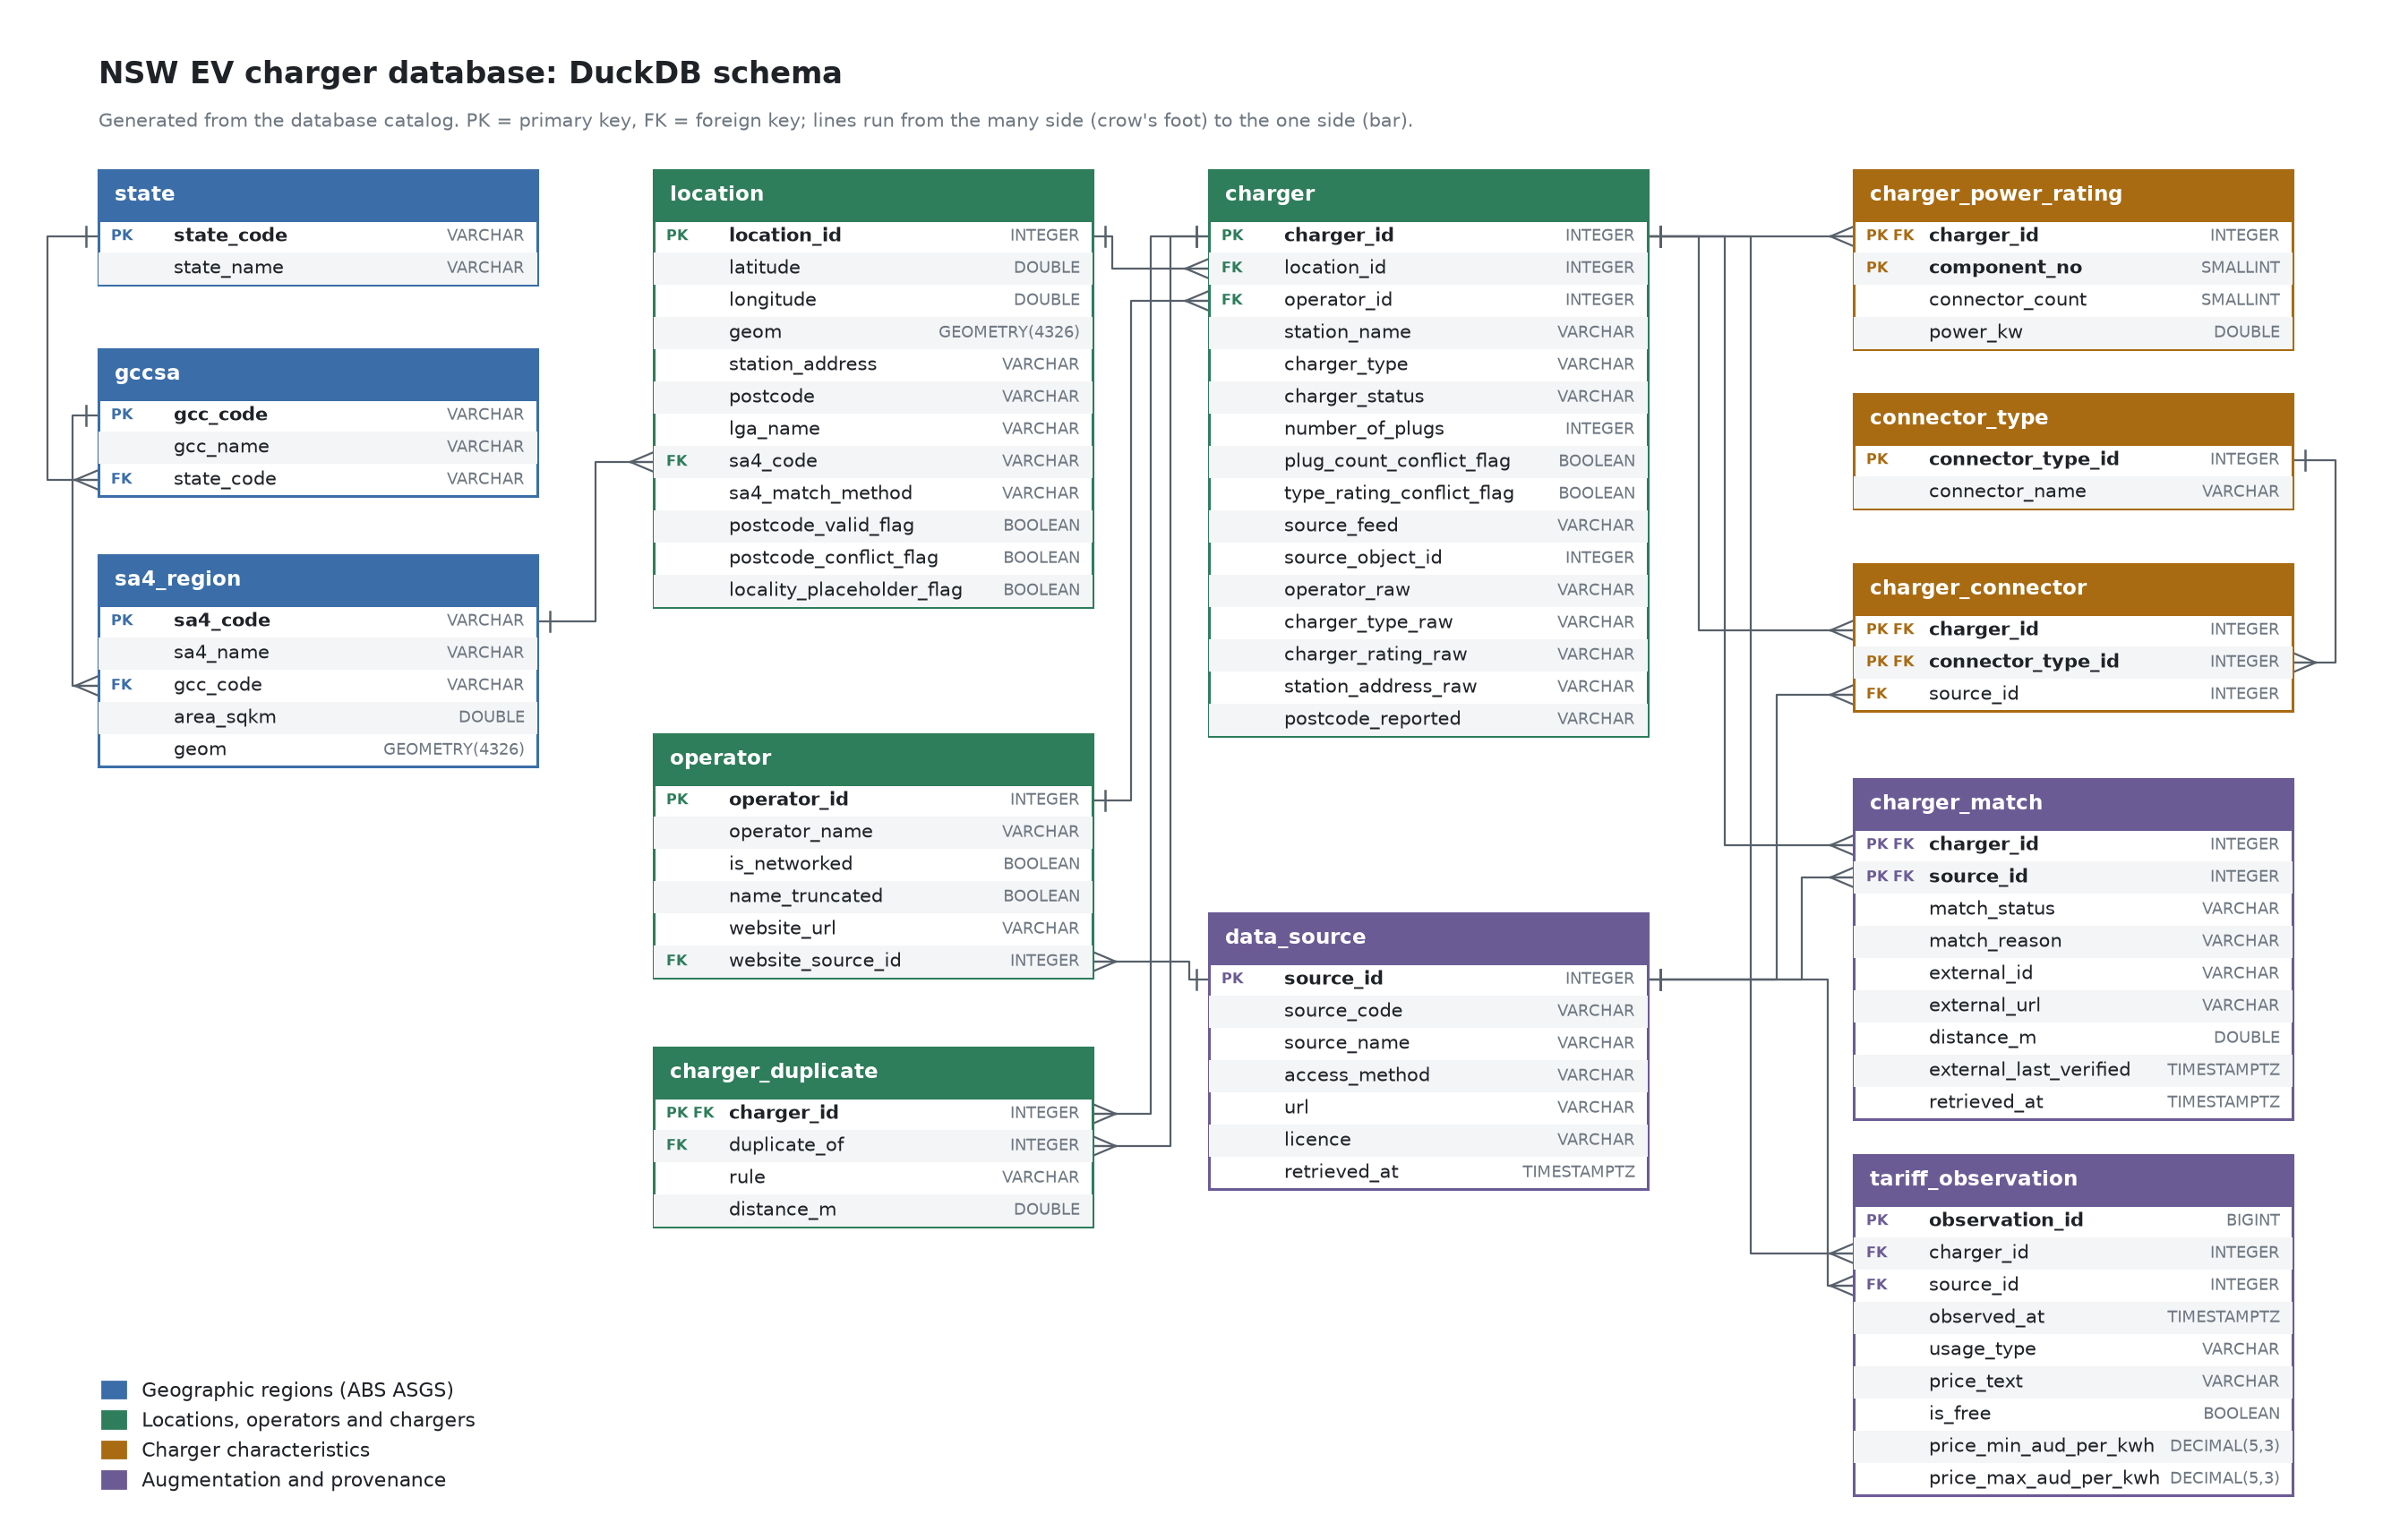

In [28]:
sys.path.insert(0, str(PROJECT_ROOT))
from tools.schema_diagram import draw_schema_diagram

draw_schema_diagram(con, DIAGRAM_PATH, title="NSW EV charger database: DuckDB schema")
print(f"Saved {DIAGRAM_PATH.relative_to(PROJECT_ROOT)}")
display(Image(filename=str(DIAGRAM_PATH), width=1100))

<a id="summary"></a>
## 9. Summary and outputs

The connection is closed, and the file is reopened read-only as a fresh reader would open it. The
check confirms that what was verified in memory also holds on disk: the CRS is still part of both
geometry columns, and the tables and views are all present.

In [29]:
con.execute("CHECKPOINT")
con.close()

with duckdb.connect(str(DB_PATH), read_only=True) as reader:
    reader.execute("LOAD spatial")
    on_disk = reader.sql("""
        SELECT t.table_name, t.estimated_size AS rows,
               string_agg(c.data_type, ', ') FILTER (WHERE c.data_type LIKE 'GEOMETRY%') AS geometry
        FROM duckdb_tables() AS t
        LEFT JOIN duckdb_columns() AS c USING (database_name, table_name)
        WHERE t.database_name = current_database()
        GROUP BY t.table_name, t.estimated_size
        ORDER BY t.table_name
    """).df()
    views = reader.execute(
        "SELECT COUNT(*) FROM duckdb_views() WHERE schema_name = 'main' AND NOT internal"
    ).fetchone()[0]

assert on_disk["geometry"].dropna().eq(f"GEOMETRY('{TARGET_CRS}')").all()
assert views == 3
print(f"{DB_PATH.relative_to(PROJECT_ROOT)}: {DB_PATH.stat().st_size / 1e6:.1f} MB, "
      f"{len(on_disk)} tables, {views} views")
display(on_disk)

data/processed/ev_chargers.duckdb: 27.0 MB, 13 tables, 3 views


,table_name,rows,geometry
0,charger,1940,None
1,charger_connector,508,None
2,charger_duplicate,22,None
3,charger_match,736,None
4,charger_power_rating,1520,None
5,connector_type,2,None
6,data_source,4,None
7,gccsa,2,None
8,location,1929,GEOMETRY('EPSG:4326')
9,operator,42,None


### What Task 4 produced

| File | Contents |
|---|---|
| `sql/schema.sql` | DDL for the complete schema, re-runnable, with a storage-format guard |
| `data/processed/ev_chargers.duckdb` | The populated database (DuckDB ≥ 1.5, storage format v1.5.0) |
| `docs/schema_diagram.png` | Entity-relationship diagram of the schema |
| `tools/schema_diagram.py` | Draws the diagram from the database catalog |

### Design decisions, in brief

* **3NF base tables, denormalised views.** Every fact is stored once. `v_charger_detail` rebuilds
  Task 3's flat file exactly, except for the ten shared sites that now hold a single address
  (section 6.3).
* **Locations separate from chargers**, because the SA4, postcode and coordinates depend on the site
  (verified in section 5.4), and one site can hold AC and DC units from different operators.
* **Repeating and multi-valued attributes get their own tables**: compound power ratings, plug
  types, and time-stamped price observations ready for Assignment 2.
* **Probable duplicates are linked, not deleted.** `charger_duplicate` records which charger each
  flagged record duplicates, and why, so a query can count physical chargers
  (`WHERE NOT is_probable_duplicate`) or records, as it needs.
* **Provenance is data.** `data_source` and `charger_match` record where every augmented value came
  from and why unmatched chargers were not augmented.
* **The spatial design is enforced, not assumed.** CRS-typed geometry rejects un-reprojected
  polygons, a CHECK ties the point to its coordinates, R-tree indexes serve spatial predicates, and
  the storage format is pinned so none of this is lost on disk.

### Limitations and open points

* The database file needs **DuckDB 1.5 or later** to open. That is the price of keeping the CRS in
  the column type; `requirements.txt` therefore pins `duckdb>=1.5`.
* Price parsing is conservative: strings that do not state a per-kWh amount explicitly stay
  unparsed (section 5.10). Their text is kept, so a better rule can be applied later.
* Three operator names are truncated at source with no full form in the data (`University of`,
  `Energy Austra`, `Fast Cities A`). They are stored as Task 2 left them, with
  `operator.name_truncated = TRUE`.
* The coverage views count charger *records*. Of those, 22 are probable duplicates, marked by the
  `probable_duplicates` column of `v_sa4_coverage` and the `is_probable_duplicate` column of
  `v_charger_detail`.
* OCM prices and plug types are community-maintained and were last verified up to several years ago
  (section 6.5). The match log records the verification date, so stale values can be identified.